# Kaggle 커머스 시계열 · 드리프트 실험

**날짜:** 2026-08-13  
**선행:** `01_commerce_timeseries_drift.ipynb` (UCI / Olist mirror / Superstore)

이번 노트북은 Kaggle API(`~/.kaggle/access_token`)로 받은 셋을 대상으로 한다.

| 데이터 | 접근 | grain | 드리프트 초점 |
|---|---|---|---|
| Favorita (`store-sales-time-series-forecasting`) | competition download OK | store × family × day | 매출/프로모/패밀리 믹스 |
| M5 | `kagglehub.competition_download` (Rules 수락) | SKU × store × day | 계층 수요·카테고리/주 믹스 |
| Instacart | dataset mirror OK | order × product | 재구매·부서 믹스 (상대시간) |

원본은 수백만~수천만 행이므로 `lib/kaggle_data.py`가 **일별/버킷 패널**을 `data/*/panels/`에 캐시한다.

## 커머스 용어 정리

상세 정의는 `01_commerce_timeseries_drift.ipynb` 상단과 같다. 이 노트북에서 바로 나오는 핵심만 요약한다.

| 용어 | 의미 | 이 노트북에서의 쓰임 |
|---|---|---|
| **SKU / Item** | 최소 상품 단위 | M5 `item_id` / `unique_id`의 상품 부분 |
| **Category / Family / Dept** | 상품 분류 | M5 `cat_id`, Favorita `family`, Instacart `department` |
| **Store / State** | 점포·지역 | M5 `store_id`/`state_id`, Favorita `store_nbr` |
| **GMV / Sales / Units** | 거래액·매출·판매수량 | Favorita `sales`, M5 일별 `units` |
| **AOV** | 객단가 (`GMV / Orders`) | 주문 grain이 있을 때 규모 vs 단가 분리 |
| **Mix / Share** | 구성 점유율 | 카테고리·주·패밀리·부서 비중 시계열 |
| **Promo rate** | 프로모 적용 비율 | Favorita `onpromotion` |
| **Reorder rate** | 재구매 라인 비율 | Instacart `reordered` |
| **Grain** | 한 행의 해상도 | Favorita/M5: store×item×day, Instacart: order×product |
| **PSI / TV / JS** | 분포·믹스 드리프트 지표 | 윈도우 비교, 롤링 점수 |

> M5는 Academic/Non-Commercial 데이터다. 원본 CSV는 재배포하지 않는다.


## 0. 환경

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="matplotlib")
sns.set_theme(style="whitegrid", context="notebook")

NB_ROOT = Path.cwd()
if not (NB_ROOT / "lib").exists():
    NB_ROOT = Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_ROOT))

from lib.datasets import DATASET_CATALOG
from lib.drift import compare_windows, rolling_drift, total_variation, js_divergence
from lib.kaggle_data import (
    build_all_kaggle_panels,
    load_favorita_panels,
    load_instacart_panels,
    load_m5_panels,
)
from lib.plotting import configure_matplotlib, finish_figure, format_date_axis, plot_metric_stack, style_area

font = configure_matplotlib()
print("NB_ROOT", NB_ROOT, "| font:", font)
display(pd.DataFrame(DATASET_CATALOG).query("id in ['m5','favorita','instacart']")[
    ["id", "name", "grain", "period", "access", "why"]
])


NB_ROOT /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks | font: AppleGothic


,id,name,grain,period,access,why
4,m5,M5 Walmart Forecasting,SKU x store x day,2011-01 ~ 2016-06,kagglehub.competition_download (Rules 수락 필요),계층 시계열(점포-카테고리-SKU) 수요·믹스 드리프트 벤치마크.
5,instacart,Instacart Market Basket 2017,order + order_product,"상대 시간(dow/hour, days_since_prior)",Kaggle API (access_token),재구매/장바구니 구성 드리프트. 절대 날짜 대신 order_number 축.
6,favorita,Corporación Favorita Store Sales,store x family x day,2013-01 ~ 2017-08,Kaggle API (Rules 수락된 계정),프로모션/휴일/유가 공변량과 점포·카테고리 수요 시계열.


## 1. 다운로드 · 패널 빌드

이미 받아 둔 파일은 재사용한다. M5는 `kagglehub.competition_download('m5-forecasting-accuracy')` 로
공식 CSV를 받고, Rules 미수락 시에만 parquet 미러로 폴백한다.

In [2]:
paths = build_all_kaggle_panels(force=False)
m5_source = (NB_ROOT / 'data' / 'm5' / 'panels' / 'source.txt')
print('M5 panel source:', m5_source.read_text().strip() if m5_source.exists() else 'missing')
for name, panel_map in paths.items():
    print(f"\n[{name}]")
    for k, p in panel_map.items():
        print(f"  {k:24s} {p.exists()}  {p.stat().st_size if p.exists() else 0:,} bytes")

M5 panel source: official

[m5]
  daily_total              True  28,896 bytes
  daily_cat                True  47,522 bytes
  daily_state              True  48,613 bytes
  series_meta              True  257,315 bytes

[favorita]
  daily_total              True  32,042 bytes
  daily_family             True  287,538 bytes
  daily_store              True  216,553 bytes
  daily_promo_rate         True  25,379 bytes
  tx_daily                 True  25,604 bytes

[instacart]
  by_order_number          True  5,817 bytes
  by_dow_hour              True  6,199 bytes
  dept_mix_by_ordernum     True  22,961 bytes
  reorder_by_ordernum      True  2,143 bytes


## 2. Favorita — 점포 × 패밀리 수요 + 프로모션

절대 날짜가 있는 계층 시계열. 공변량으로 `onpromotion`, `transactions`, (원본에) oil/holiday가 있다.

**KPI 스택 해석**
- **sales:** 일별 매출 규모. 연한 선=일별, 진한 선=7일 이동평균.
- **promo_rate:** 프로모 적용 비율. sales와 같이 오르면 “프로모로 끌어올린 매출” 후보.
- **transactions:** 거래 건수. sales↑·transactions 정체면 객단가/구성 쪽을 의심.


Favorita 기간: 2013-01-01 ~ 2017-08-15 days= 1684


,count,mean,std,min,25%,50%,75%,max
sales,1684.0,637556.4,234410.2,2511.6,442711.5,632188.9,785945.5,1463084.0


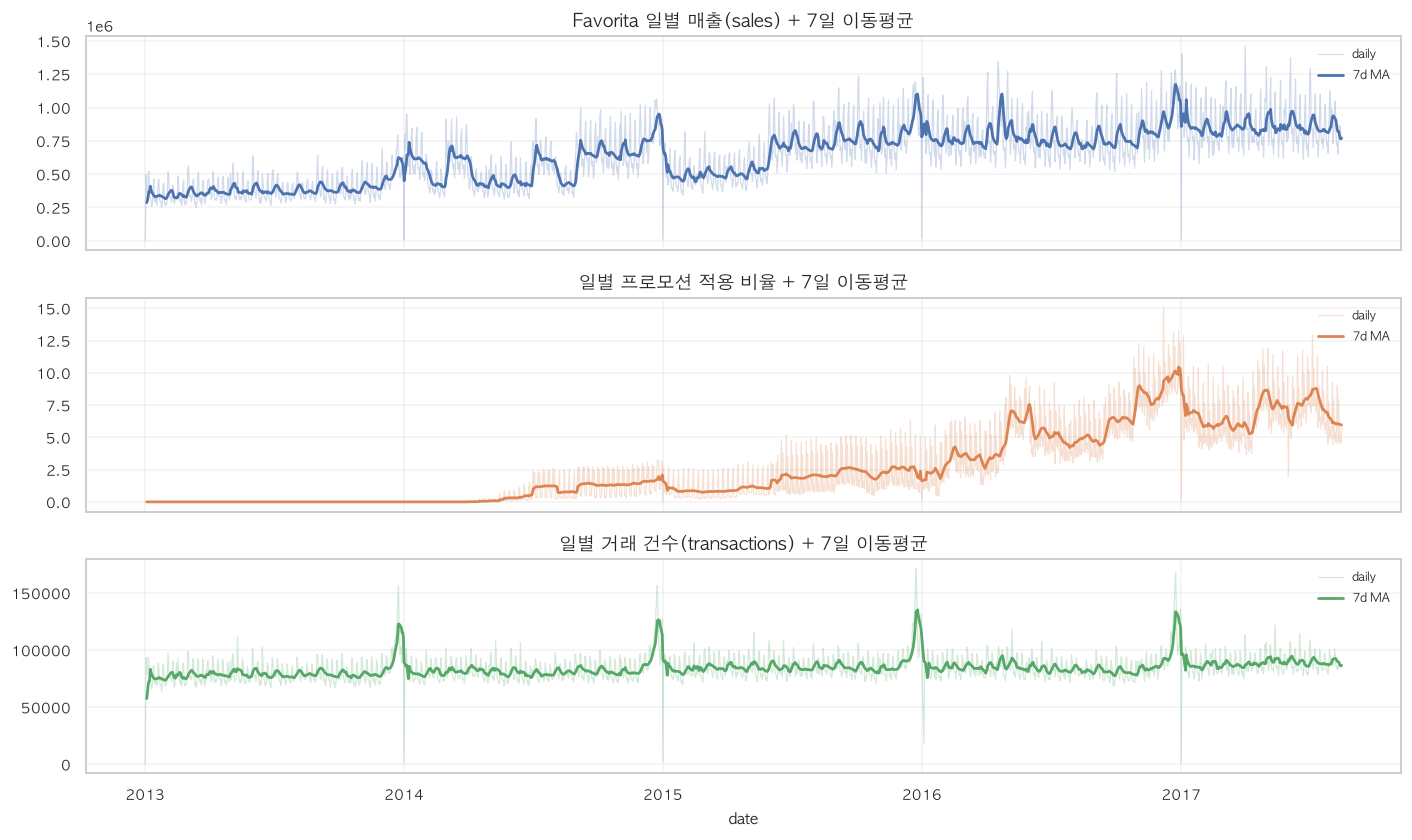

In [3]:
fav = load_favorita_panels()
daily = fav["daily_total"].copy()
daily.index = pd.to_datetime(daily.index)
promo = fav["daily_promo_rate"].copy()
promo.index = pd.to_datetime(promo.index)
tx = fav["tx_daily"].copy()
tx.index = pd.to_datetime(tx.index)
family = fav["daily_family"].copy()
family.index = pd.to_datetime(family.index)

print("Favorita 기간:", daily.index.min().date(), "~", daily.index.max().date(), "days=", len(daily))
display(daily.describe().T.round(1))

plot_metric_stack(
    {
        "sales": daily["sales"],
        "promo_rate": promo["promo_rate"],
        "transactions": tx["transactions"],
    },
    title_map={
        "sales": "Favorita 일별 매출(sales) + 7일 이동평균",
        "promo_rate": "일별 프로모션 적용 비율 + 7일 이동평균",
        "transactions": "일별 거래 건수(transactions) + 7일 이동평균",
    },
    colors={"sales": "C0", "promo_rate": "C1", "transactions": "C2"},
)

**Family 믹스 area — 해석**
- 세로축은 매출이 아니라 **family 점유율**. 밴드 두께=해당 family 비중.
- 총 sales가 커져도 밴드 구성이 바뀌면 **상품군 믹스 드리프트**.
- 아래 TV/JS는 2015 vs 2016 family 합계 점유율 거리(클수록 구성 변화 큼).


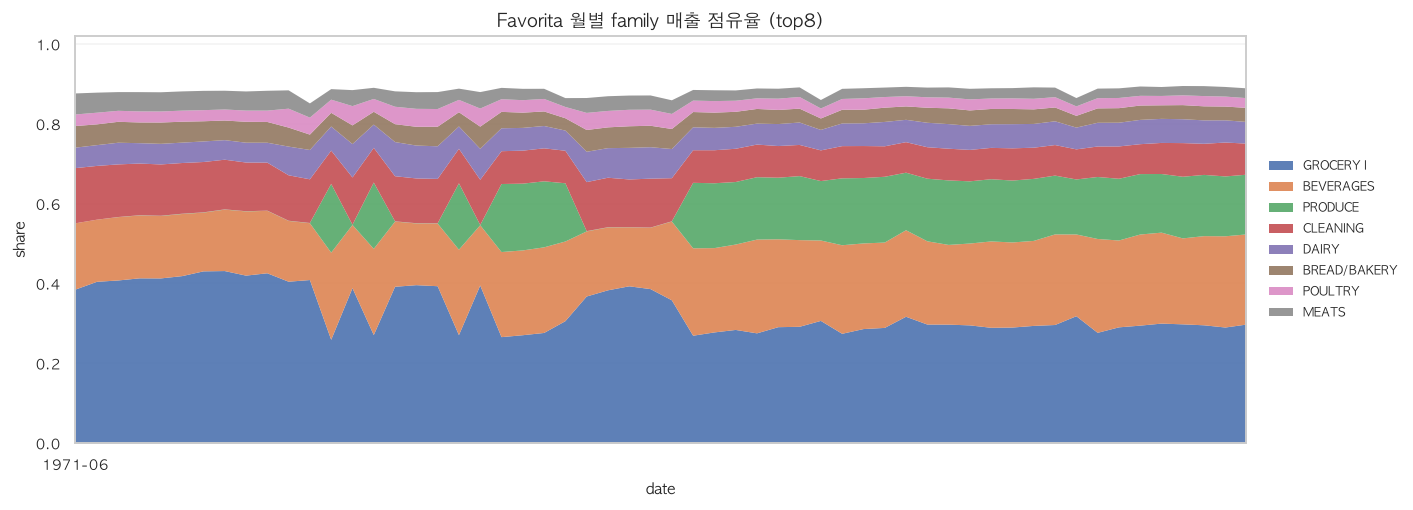

family mix TV 2015 vs 2016: 0.0657
family mix JS 2015 vs 2016: 0.0036


In [4]:
# family mix (top 8 by total)
top = family.sum().sort_values(ascending=False).head(8).index
mix = family[top].div(family.sum(axis=1), axis=0)
monthly = mix.resample("MS").mean()

fig, ax = plt.subplots(figsize=(13, 4.8))
monthly.plot.area(ax=ax, stacked=True, alpha=0.9, linewidth=0)
style_area(ax, "Favorita 월별 family 매출 점유율 (top8)")
format_date_axis(ax, locator="month")
fig.tight_layout()
plt.show()

base = (family.index >= "2015-01-01") & (family.index < "2016-01-01")
cur = (family.index >= "2016-01-01") & (family.index < "2017-01-01")
print("family mix TV 2015 vs 2016:", round(total_variation(family.loc[base].sum(), family.loc[cur].sum()), 4))
print("family mix JS 2015 vs 2016:", round(js_divergence(family.loc[base].sum(), family.loc[cur].sum()), 4))

**윈도우 비교·롤링 드리프트 — 해석**
- 표: 2015 vs 2016 sales·promo_rate 분포 차이(PSI/KS 등)와 family 믹스 지표.
- **롤링 PSI/KS:** 첫 30일을 베이스로 이후 창이 얼마나 다른지. 상승 구간 ≈ 분포가 베이스에서 멀어진 시기.
- 프로모 강도 변화와 sales 드리프트 시점이 겹치면 원인 후보로 연결해 본다.


,baseline_mean,current_mean,mean_rel_change,psi,dist_ks_stat,dist_ks_pvalue,dist_wasserstein,mix_tv,mix_js
sales,661758.5183,790834.3095,0.1950,1.7459,0.3111,0.0,129075.7912,0.0657,0.0036
promo_rate,1.6762,5.4035,2.2236,2.9627,0.6598,0.0,3.7273,NaN,NaN


/Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks/lib/plotting.py:58: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  for label in ax.get_xticklabels():
/var/folders/9c/d9bwhd_11tqdj2jhtjf0wmh80000gn/T/ipykernel_22447/1402359528.py:22: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.tight_layout()
/Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.canvas.print_figure(bytes_io, **kw)


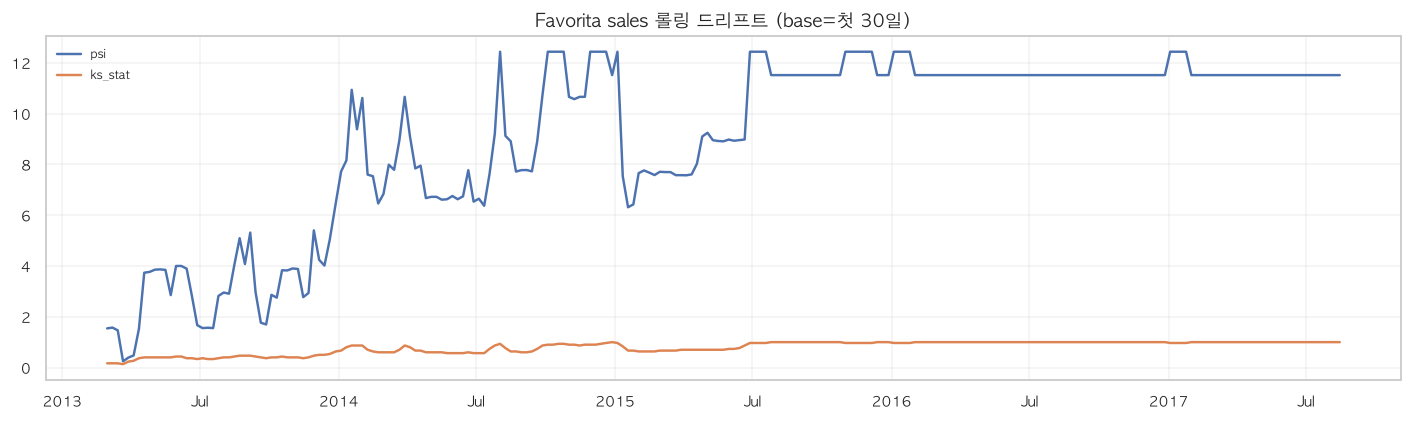

In [5]:
sales_cmp = compare_windows(
    daily["sales"],
    ("2015-01-01", "2015-12-31"),
    ("2016-01-01", "2016-12-31"),
    mix_base=family.loc["2015"].sum(),
    mix_cur=family.loc["2016"].sum(),
)
promo_cmp = compare_windows(
    promo["promo_rate"],
    ("2015-01-01", "2015-12-31"),
    ("2016-01-01", "2016-12-31"),
)
display(pd.DataFrame({"sales": sales_cmp, "promo_rate": promo_cmp}).T.round(4))

roll = rolling_drift(daily["sales"].interpolate(limit_direction="both"), window=30, step=7)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll.index, roll["psi"], label="psi", lw=1.6)
ax.plot(roll.index, roll["ks_stat"], label="ks_stat", lw=1.6)
ax.set_title("Favorita sales 롤링 드리프트 (base=첫 30일)")
ax.legend(frameon=False)
format_date_axis(ax)
fig.tight_layout()
plt.show()

## 3. M5 — 계층 수요 (카테고리 / 주)

`unique_id = {CAT}_{DEPT}_{ITEM}_{STATE}_{STORE}`.  
공식 `sales_train_evaluation.csv` + `calendar.csv` 로 일별 패널을 만든다.

**시계열 해석**
- 위: 일별 총 **units**(연함) + 7일 MA(진함). 주간 요철이 강하면 캘린더 효과가 큰 셋.
- 아래: 카테고리별 7일 MA. 수준만 다르고 모양이 비슷하면 공통 계절, 모양이 갈라지면 카테고리 고유 시프트.


M5 기간: 2011-01-29 ~ 2016-05-22 days= 1941
series: 30490 cats: 3 states: 3 stores: 10


,n_series
cat,
FOODS,14370
HOUSEHOLD,10470
HOBBIES,5650


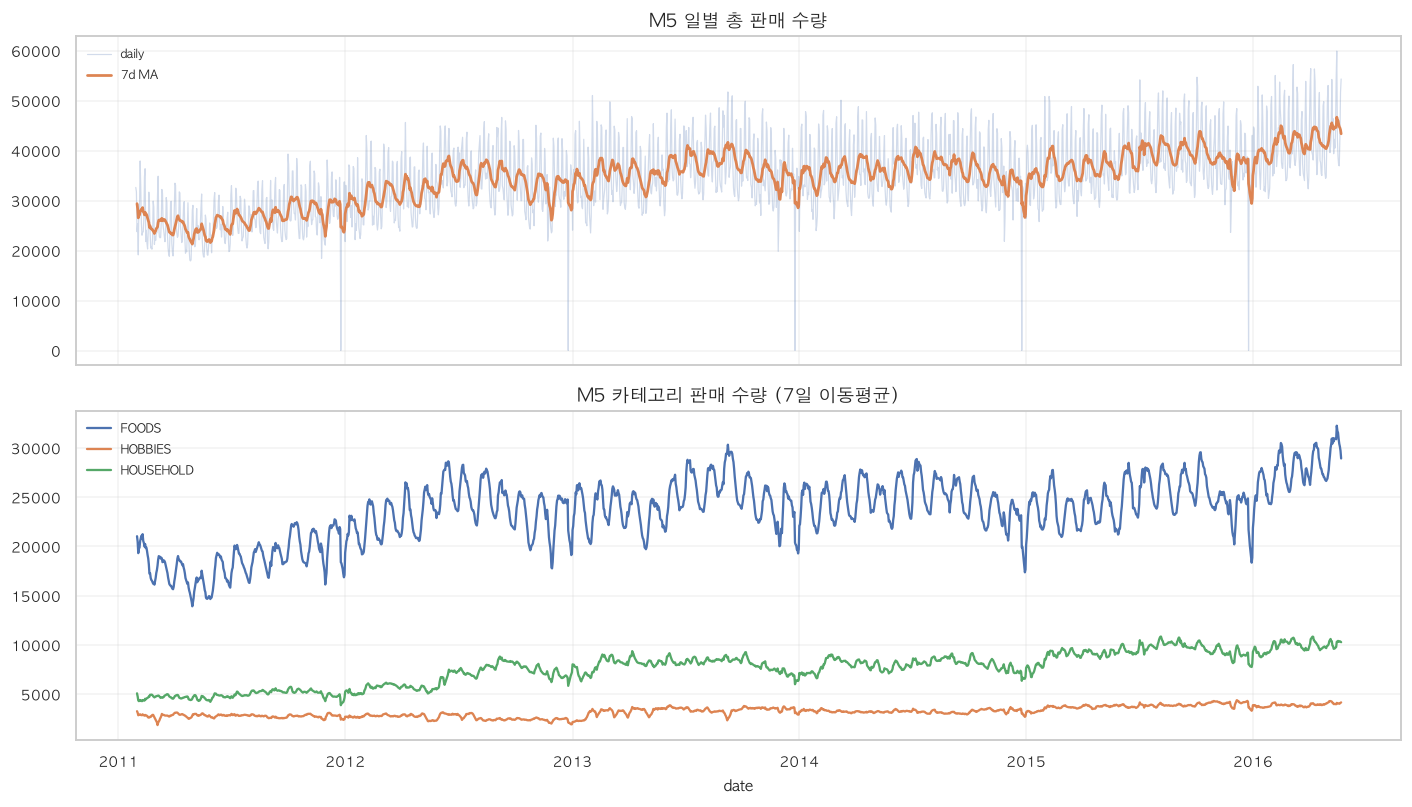

In [6]:
m5 = load_m5_panels()
total = m5["daily_total"].copy()
total.index = pd.to_datetime(total.index)
cat = m5["daily_cat"].copy()
cat.index = pd.to_datetime(cat.index)
state = m5["daily_state"].copy()
state.index = pd.to_datetime(state.index)
meta = m5["series_meta"]

print("M5 기간:", total.index.min().date(), "~", total.index.max().date(), "days=", len(total))
print("series:", len(meta), "cats:", meta["cat"].nunique(), "states:", meta["state"].nunique(), "stores:", meta["store"].nunique())
display(meta["cat"].value_counts().to_frame("n_series"))

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
axes[0].plot(total.index, total["units"], alpha=0.25, lw=0.8, label="daily")
axes[0].plot(total.index, total["units"].rolling(7, min_periods=3).mean(), lw=1.8, label="7d MA")
axes[0].set_title("M5 일별 총 판매 수량")
axes[0].legend(frameon=False, loc="upper left")
for col in cat.columns:
    axes[1].plot(cat.index, cat[col].rolling(7, min_periods=3).mean(), lw=1.5, label=col)
axes[1].set_title("M5 카테고리 판매 수량 (7일 이동평균)")
axes[1].legend(loc="upper left", frameon=False)
finish_figure(fig, axes, date_axis=True)

**믹스·롤링 — 해석**
- area: **카테고리/주(state) 점유율**. 총 units와 별개로 “무엇이 팔렸는지·어디서 팔렸는지” 구성.
- 표/TV: 2014 vs 2015 분포·믹스 거리.
- 롤링 드리프트: units 분포가 베이스(첫 창)에서 언제 멀어지는지. 계층 믹스는 안정적인데 units PSI만 크면 **수준/계절** 쪽을 먼저 의.


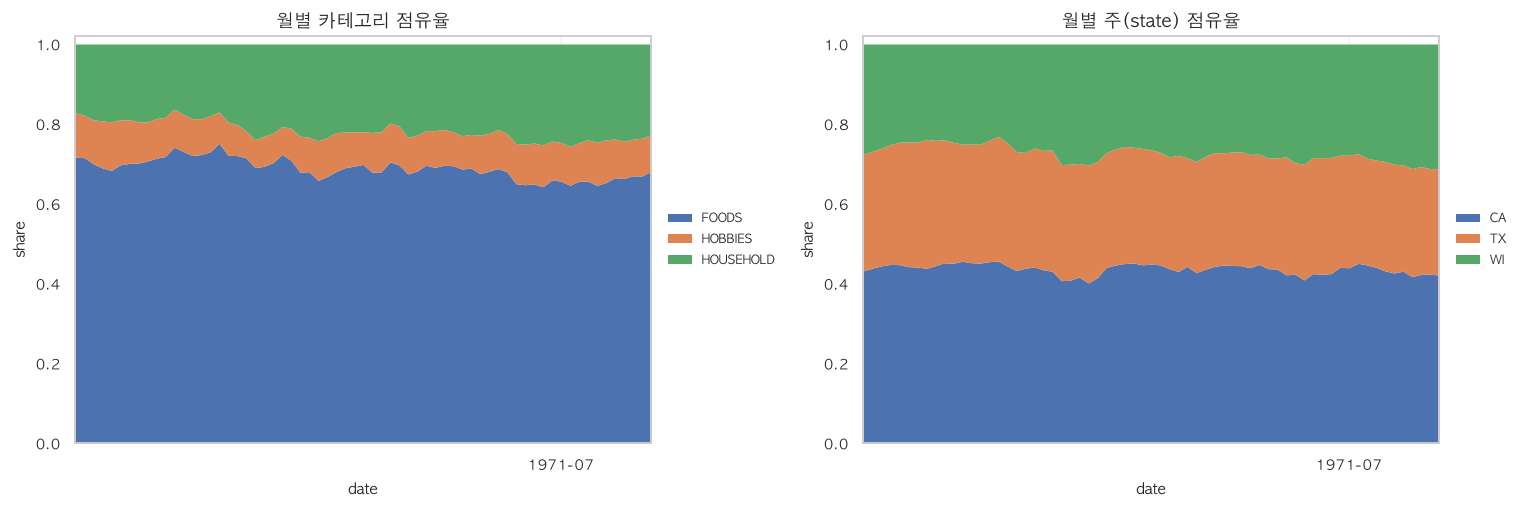

,baseline_mean,current_mean,mean_rel_change,psi,dist_ks_stat,dist_ks_pvalue,dist_wasserstein,mix_tv,mix_js
2014 vs 2015,35862.4,37810.4411,0.0543,0.1364,0.1781,0.0,1948.074,0.0341,0.0007


state mix TV 2014 vs 2015: 0.0078


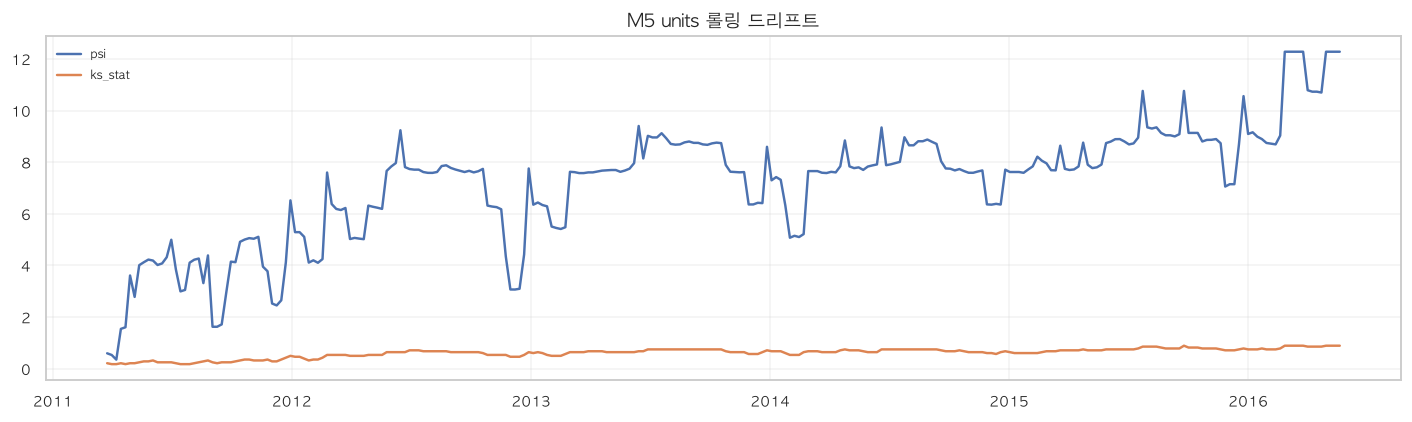

In [7]:
cat_share = cat.div(cat.sum(axis=1), axis=0)
state_share = state.div(state.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=False)
cat_share.resample("MS").mean().plot.area(ax=axes[0], stacked=True, linewidth=0)
style_area(axes[0], "월별 카테고리 점유율")
state_share.resample("MS").mean().plot.area(ax=axes[1], stacked=True, linewidth=0)
style_area(axes[1], "월별 주(state) 점유율")
for ax in axes:
    format_date_axis(ax, locator="month")
fig.tight_layout()
plt.show()

m5_cmp = compare_windows(
    total["units"],
    ("2014-01-01", "2014-12-31"),
    ("2015-01-01", "2015-12-31"),
    mix_base=cat.loc["2014"].sum(),
    mix_cur=cat.loc["2015"].sum(),
)
state_tv = total_variation(state.loc["2014"].sum(), state.loc["2015"].sum())
display(pd.Series(m5_cmp).to_frame("2014 vs 2015").T.round(4))
print("state mix TV 2014 vs 2015:", round(state_tv, 4))

roll = rolling_drift(total["units"].interpolate(limit_direction="both"), window=28, step=7)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll.index, roll["psi"], label="psi", lw=1.6)
ax.plot(roll.index, roll["ks_stat"], label="ks_stat", lw=1.6)
ax.set_title("M5 units 롤링 드리프트")
ax.legend(frameon=False)
format_date_axis(ax)
fig.tight_layout()
plt.show()

## 4. Instacart — 절대 날짜 없는 장바구니 드리프트

시간축이 `order_number`, `order_dow`, `order_hour_of_day` 다.
그래서 **캘린더 드리프트** 대신 **생애주기(재주문 횟수)에 따른 구성 변화**를 본다.

**2×2 차트 해석**
- **order_number별 주문 수:** 재주문이 늘수록 표본이 줄어드는(생존) 곡선이 흔하다.
- **avg days_since_prior_order:** 주문 간격. 생애 후반에 간격이 짧/길어지는지.
- **reorder_rate:** 재구매 라인 비율. order_number↑에 따라 오르면 “단골 장바구니”로 읽는다.
- **dow × hour 히트맵:** 셀=해당 요일·시각 주문량(또는 건수). 진한 칸 = **그 요일·그 시간대에 주문이 많다**
  (예: 오전 × 주말이 진하면 “주말 오전에 평균적으로 주문이 몰린다”).


order_number max: 100 dept columns: ['alcohol', 'babies', 'bakery', 'beverages', 'breakfast', 'bulk', 'canned goods', 'dairy eggs'] ...


,orders,users,avg_days_since
order_number,,,
1,206209,206209,NaN
2,206209,206209,15.342129
3,206209,206209,15.287015
4,206209,206209,15.430185
5,182223,182223,14.820571


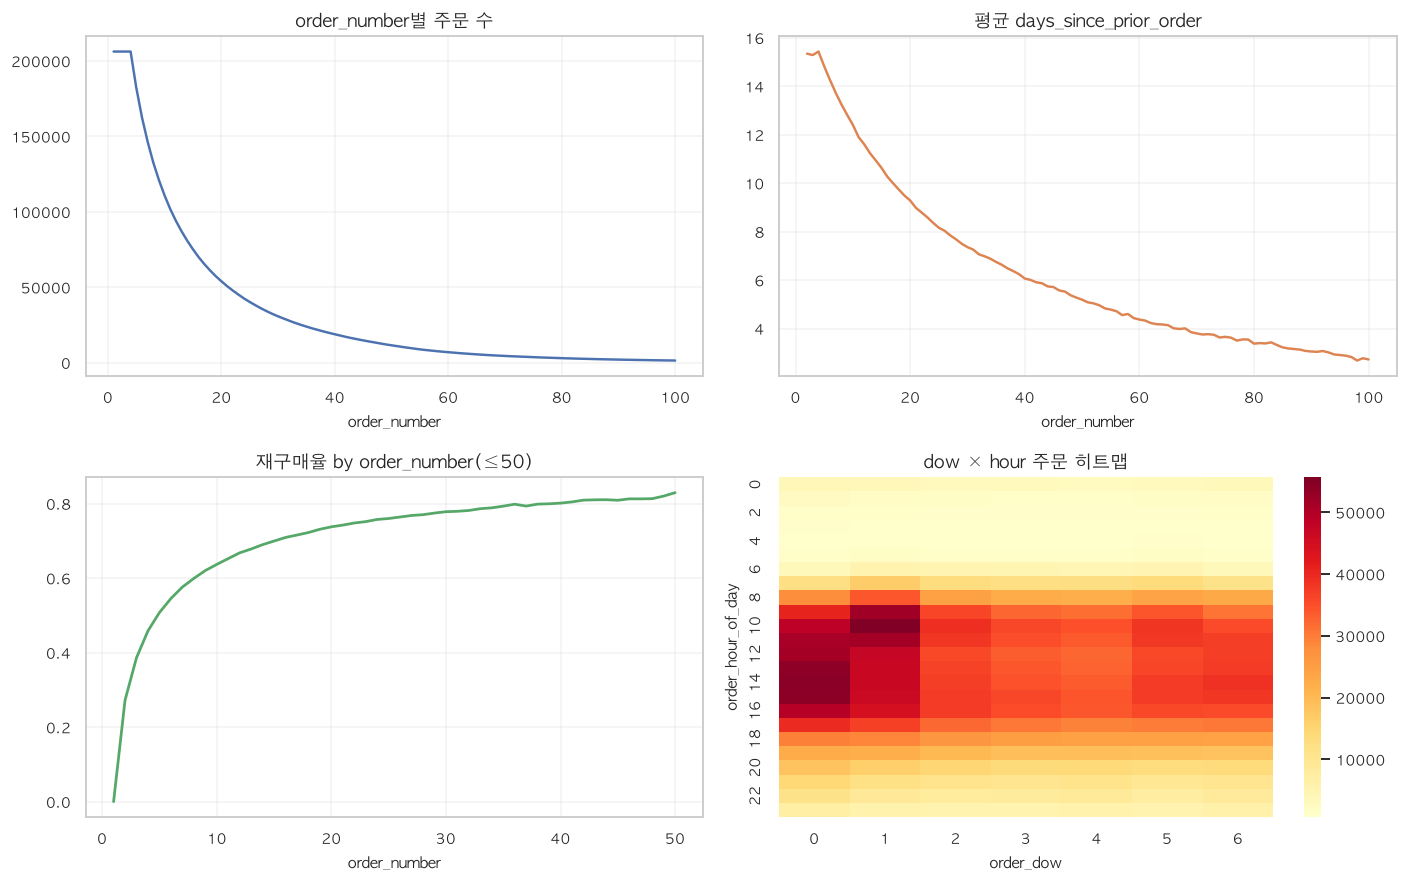

In [8]:
ins = load_instacart_panels()
by_n = ins["by_order_number"]
dow = ins["by_dow_hour"]
dept = ins["dept_mix_by_ordernum"]
reorder = ins["reorder_by_ordernum"]

print("order_number max:", by_n.index.max(), "dept columns:", list(dept.columns)[:8], "...")
display(by_n.head())

fig, axes = plt.subplots(2, 2, figsize=(13, 8.2))
axes[0, 0].plot(by_n.index, by_n["orders"], lw=1.6)
axes[0, 0].set_title("order_number별 주문 수")
axes[0, 0].set_xlabel("order_number")
axes[0, 1].plot(by_n.index, by_n["avg_days_since"], color="C1", lw=1.6)
axes[0, 1].set_title("평균 days_since_prior_order")
axes[0, 1].set_xlabel("order_number")
axes[1, 0].plot(reorder.index, reorder["reorder_rate"], color="C2", lw=1.8)
axes[1, 0].set_title("재구매율 by order_number(≤50)")
axes[1, 0].set_xlabel("order_number")
sns.heatmap(dow, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("dow × hour 주문 히트맵")
axes[1, 1].set_xlabel("order_dow")
axes[1, 1].set_ylabel("order_hour_of_day")
fig.tight_layout()
plt.show()

**부서 믹스 by order_number — 해석**
- x=`order_number`(상대 시간), 밴드=`department` 점유율.
- 초반(첫 주문대) vs 후반(20–30회) 밴드가 달라지면 **생애주기에 따른 장바구니 구성 드리프트**.
- 아래 TV/JS·reorder 평균은 early vs late를 숫자로 요약한 것.


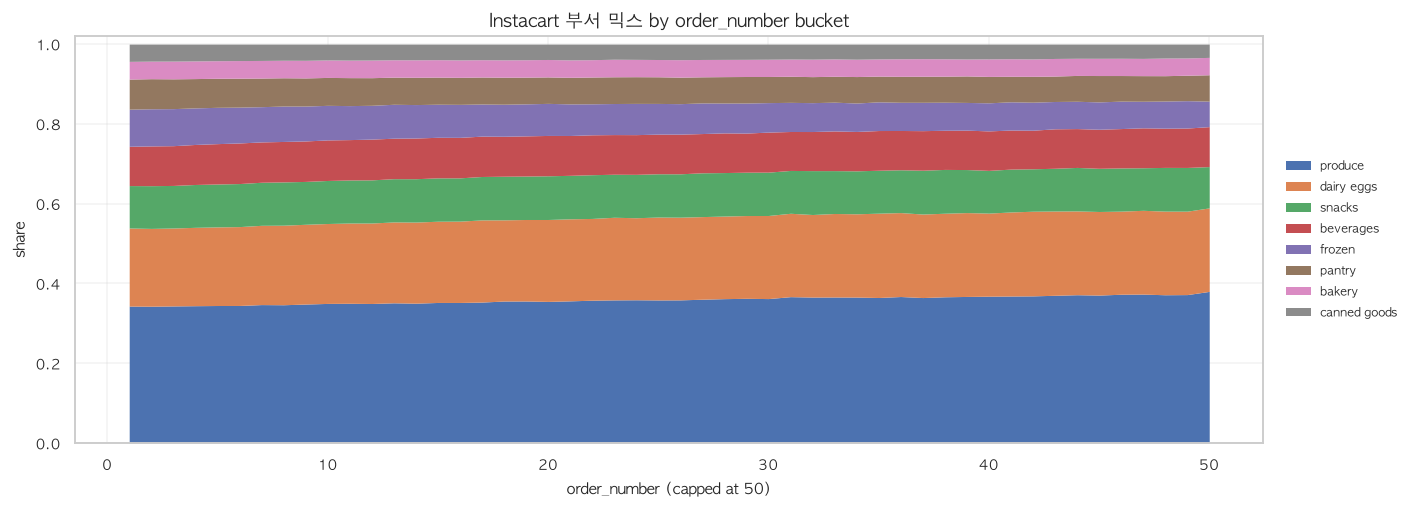

dept mix TV early(2-5) vs late(20-30): 0.0363
dept mix JS early vs late: 0.001
reorder_rate early: 0.4061 late: 0.7591


In [9]:
# top departments for readability
top_dept = dept.sum().sort_values(ascending=False).head(8).index
dept_top = dept[top_dept].div(dept[top_dept].sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 4.8))
dept_top.plot.area(ax=ax, stacked=True, linewidth=0)
style_area(ax, "Instacart 부서 믹스 by order_number bucket")
ax.set_xlabel("order_number (capped at 50)")
ax.set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

# early (2-5) vs late (20-30) basket mix
early = dept.loc[2:5].sum()
late = dept.loc[20:30].sum()
print("dept mix TV early(2-5) vs late(20-30):", round(total_variation(early, late), 4))
print("dept mix JS early vs late:", round(js_divergence(early, late), 4))
print("reorder_rate early:", round(reorder.loc[2:5, "reorder_rate"].mean(), 4),
      "late:", round(reorder.loc[20:30, "reorder_rate"].mean(), 4))

## 5. 종합 인사이트 (Kaggle 셋)

| 데이터 | 시간축 | 핵심 슬롯 | 관측 |
|---|---|---|---|
| Favorita | 달력 | sales, promo_rate, family/store mix | 성장 + 프로모 강도 변화, family 믹스 TV는 중~소 |
| M5 | 달력 | units, cat/state mix | 강한 주간 계절. 계층 믹스는 상대적으로 안정적일 수 있음 |
| Instacart | order_number / dow-hour | reorder_rate, dept mix | 재주문 횟수가 늘수록 reorder↑, 장바구니 구성 이동 |

커머스 도메인 킷에 넣으면 좋은 확장:

1. **계층 믹스 슬롯** (cat / store / state) — M5·Favorita 패턴
2. **프로모션 조건부 드리프트** — Favorita `onpromotion`
3. **상대시간/퍼널 슬롯** — Instacart처럼 절대 시각이 없을 때 order_number·재구매율
4. **Rules 게이트** — M5는 토큰 + Rules 수락이 필요 (`kagglehub.competition_download`)
5. **라이선스** — M5는 Academic/Non-Commercial; 원본 데이터는 재배포하지 말 것

In [10]:
summary = pd.DataFrame(
    [
        ["Favorita", "calendar", "sales PSI / family TV / promo_rate", "promo 공변량 조건부 드리프트에 적합"],
        ["M5 (official)", "calendar + hierarchy", "units PSI / cat·state mix", "kagglehub 공식 CSV 패널"],
        ["Instacart", "order_number / dow-hour", "reorder_rate / dept mix TV", "절대날짜 없는 커머스 이벤트 로그 템플릿"],
    ],
    columns=["dataset", "time_axis", "drift_slots", "note"],
)
display(summary)

,dataset,time_axis,drift_slots,note
0,Favorita,calendar,sales PSI / family TV / promo_rate,promo 공변량 조건부 드리프트에 적합
1,M5 (official),calendar + hierarchy,units PSI / cat·state mix,kagglehub 공식 CSV 패널
2,Instacart,order_number / dow-hour,reorder_rate / dept mix TV,절대날짜 없는 커머스 이벤트 로그 템플릿
